**Capstone Project 2 — Group 8 | St. Clair College | Winter 2026**

Trains exactly two models and saves them:
- **Model 1:** Random Forest → `profit_margin_calc`
- **Model 2:** ExtraTrees   → `charity_care_ratio`

Run all cells top to bottom. Both `.pkl` files will be saved to `OUTPUT_DIR`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print('Libraries loaded')

Libraries loaded


In [2]:
# Paths

DATASET_PATH = r"C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\ML Modelling\ml_dataset.csv"
OUTPUT_DIR   = r"C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\app\models"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output directory: {OUTPUT_DIR}')

Output directory: C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\app\models


In [3]:
# Load dataset

df = pd.read_csv(DATASET_PATH)

# Rename 'Other' to a clean descriptive name
# This column is the BLS other healthcare occupations wages, which is a key feature for our models. Renaming it will improve code readability and maintainability.
if 'Other' in df.columns:
    df.rename(columns={'Other': 'other_healthcare_occupations_wages'}, inplace=True)
    print('Renamed: Other -> other_healthcare_occupations_wages')

print(f'Dataset shape: {df.shape}')
print(f'Years: {df["year"].min()} – {df["year"].max()}')

Renamed: Other -> other_healthcare_occupations_wages
Dataset shape: (69555, 51)
Years: 2012 – 2022


In [4]:
# Feature lists

CATEGORICAL_FEATURES = [
    'provider_type',
    'ccn_facility_type',
    'type_of_control',
    'rural_urban',
]

NUMERICAL_FEATURES = [
    # Temporal
    'year',
    # Capacity & throughput
    'number_of_beds',
    'total_bed_days_available',
    'occupancy_rate',
    'total_discharges__v___xviii___xix___unknown_',
    'total_days__v___xviii___xix___unknown_',
    # Staffing
    'fte___employees_on_payroll',
    'staff_to_bed_ratio',
    # Operational ratios
    'revenue_per_bed',
    'discharges_per_bed',
    'avg_length_of_stay',
    # Cost
    'total_other_expenses',
    # Geographic
    'rucc_code',
    # Workforce wages (BLS)
    'wage_physician',
    'wage_practitioner',
    'wage_rn',
    'wage_support',
    'other_healthcare_occupations_wages',  # renamed from 'Other'
    # Socioeconomic (Census)
    'population',
    'median_age',
    'median_income',
    'poverty_rate',
    'higher_education_rate',
]

ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES
TARGETS      = ['profit_margin_calc', 'charity_care_ratio']

# Verify every feature exists
missing = [f for f in ALL_FEATURES if f not in df.columns]
if missing:
    print(f'ERROR — missing columns: {missing}')
else:
    print(f'All {len(ALL_FEATURES)} features verified')
    print(f'  Numerical:   {len(NUMERICAL_FEATURES)}')
    print(f'  Categorical: {len(CATEGORICAL_FEATURES)}')

All 27 features verified
  Numerical:   23
  Categorical: 4


In [5]:
# Train/test split

X = df[ALL_FEATURES].copy()
y_pm  = df['profit_margin_calc'].copy()
y_ccr = df['charity_care_ratio'].copy()

X_train, X_test, y_pm_train, y_pm_test = train_test_split(
    X, y_pm, test_size=0.2, random_state=42
)
y_ccr_train = y_ccr.loc[y_pm_train.index]
y_ccr_test  = y_ccr.loc[y_pm_test.index]

print(f'Train: {X_train.shape[0]:,} rows')
print(f'Test:  {X_test.shape[0]:,} rows')

Train: 55,644 rows
Test:  13,911 rows


In [6]:
# Build pipeline

def build_pipeline(model):
    """
    Wraps any sklearn estimator in a full preprocessing pipeline:
      - Numeric:     median imputation
      - Categorical: most-frequent imputation + OneHotEncoder
    """
    preprocessor = ColumnTransformer(transformers=[
        ('num', SimpleImputer(strategy='median'), NUMERICAL_FEATURES),
        ('cat', Pipeline([
            ('imp', SimpleImputer(strategy='most_frequent')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CATEGORICAL_FEATURES),
    ])
    return Pipeline([
        ('preprocessor', preprocessor),
        ('model', model),
    ])

print('Pipeline builder defined')

Pipeline builder defined


In [7]:
# Model 1: Random Forest for Profit Margin
# Best hyperparameters from GridSearchCV in Advanced_ML_Models_V2.ipynb:
#   n_estimators=200, max_depth=None, min_samples_leaf=2, min_samples_split=2

print('Training Model 1: Random Forest → profit_margin_calc ...')

pipe_pm = build_pipeline(
    RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        min_samples_split=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
    )
)

pipe_pm.fit(X_train, y_pm_train)

pm_train_r2 = r2_score(y_pm_train, pipe_pm.predict(X_train))
pm_test_r2  = r2_score(y_pm_test,  pipe_pm.predict(X_test))
pm_mae      = mean_absolute_error(y_pm_test, pipe_pm.predict(X_test))
pm_rmse     = np.sqrt(mean_squared_error(y_pm_test, pipe_pm.predict(X_test)))

print(f'\n── Profit Margin ──')
print(f'  Train R²:  {pm_train_r2:.4f}')
print(f'  Test  R²:  {pm_test_r2:.4f}')
print(f'  Test  MAE: {pm_mae:.4f}')
print(f'  Test RMSE: {pm_rmse:.4f}')

Training Model 1: Random Forest → profit_margin_calc ...

── Profit Margin ──
  Train R²:  0.8304
  Test  R²:  0.4081
  Test  MAE: 0.0847
  Test RMSE: 0.1415


In [8]:
# 5-fold CV for Profit Margin
print('Running 5-fold CV for Profit Margin ...')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_pm = cross_val_score(
    build_pipeline(RandomForestRegressor(
        n_estimators=300, max_depth=None,
        min_samples_leaf=2, min_samples_split=2,
        max_features='sqrt', random_state=42, n_jobs=-1,
    )),
    X_train, y_pm_train, cv=kf, scoring='r2', n_jobs=-1
)

print(f'CV R² scores: {[round(s,4) for s in cv_pm]}')
print(f'Mean CV R²:   {cv_pm.mean():.4f} ± {cv_pm.std():.4f}')

Running 5-fold CV for Profit Margin ...
CV R² scores: [np.float64(0.4014), np.float64(0.3826), np.float64(0.3766), np.float64(0.4015), np.float64(0.3827)]
Mean CV R²:   0.3889 ± 0.0104


In [9]:
# Model 2: ExtraTrees for Charity Care Ratio
# Best hyperparameters from GridSearchCV in Advanced_ML_Models_V2.ipynb:
#   n_estimators=200, max_depth=None, min_samples_split=2

print('Training Model 2: ExtraTrees → charity_care_ratio ...')

pipe_ccr = build_pipeline(
    ExtraTreesRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1,
    )
)

pipe_ccr.fit(X_train, y_ccr_train)

ccr_train_r2 = r2_score(y_ccr_train, pipe_ccr.predict(X_train))
ccr_test_r2  = r2_score(y_ccr_test,  pipe_ccr.predict(X_test))
ccr_mae      = mean_absolute_error(y_ccr_test, pipe_ccr.predict(X_test))
ccr_rmse     = np.sqrt(mean_squared_error(y_ccr_test, pipe_ccr.predict(X_test)))

print(f'\n── Charity Care Ratio ──')
print(f'  Train R²:  {ccr_train_r2:.4f}')
print(f'  Test  R²:  {ccr_test_r2:.4f}')
print(f'  Test  MAE: {ccr_mae:.4f}')
print(f'  Test RMSE: {ccr_rmse:.4f}')

Training Model 2: ExtraTrees → charity_care_ratio ...

── Charity Care Ratio ──
  Train R²:  1.0000
  Test  R²:  0.5957
  Test  MAE: 0.0102
  Test RMSE: 0.0185


In [10]:
# 5-fold CV for Charity Care Ratio
print('Running 5-fold CV for Charity Care Ratio ...')

cv_ccr = cross_val_score(
    build_pipeline(ExtraTreesRegressor(
        n_estimators=300, max_depth=None,
        min_samples_split=2, min_samples_leaf=1,
        max_features='sqrt', random_state=42, n_jobs=-1,
    )),
    X_train, y_ccr_train, cv=kf, scoring='r2', n_jobs=-1
)

print(f'CV R² scores: {[round(s,4) for s in cv_ccr]}')
print(f'Mean CV R²:   {cv_ccr.mean():.4f} ± {cv_ccr.std():.4f}')

Running 5-fold CV for Charity Care Ratio ...
CV R² scores: [np.float64(0.5649), np.float64(0.5523), np.float64(0.5564), np.float64(0.5613), np.float64(0.5482)]
Mean CV R²:   0.5566 ± 0.0060


In [11]:
# Summarize results

results = pd.DataFrame({
    'Target':      ['Profit Margin', 'Charity Care Ratio'],
    'Model':       ['Random Forest (300 trees)', 'ExtraTrees (300 trees)'],
    'Train R²':    [round(pm_train_r2, 4), round(ccr_train_r2, 4)],
    'Test R²':     [round(pm_test_r2,  4), round(ccr_test_r2,  4)],
    'CV R² Mean':  [round(cv_pm.mean(), 4), round(cv_ccr.mean(), 4)],
    'CV R² Std':   [round(cv_pm.std(),  4), round(cv_ccr.std(),  4)],
    'Test MAE':    [round(pm_mae,  4), round(ccr_mae,  4)],
    'Test RMSE':   [round(pm_rmse, 4), round(ccr_rmse, 4)],
})

print('\n══════════════════════════════════════════')
print('  FINAL MODEL RESULTS')
print('══════════════════════════════════════════')
print(results.to_string(index=False))


══════════════════════════════════════════
  FINAL MODEL RESULTS
══════════════════════════════════════════
            Target                     Model  Train R²  Test R²  CV R² Mean  CV R² Std  Test MAE  Test RMSE
     Profit Margin Random Forest (300 trees)    0.8304   0.4081      0.3889     0.0104    0.0847     0.1415
Charity Care Ratio    ExtraTrees (300 trees)    1.0000   0.5957      0.5566     0.0060    0.0102     0.0185


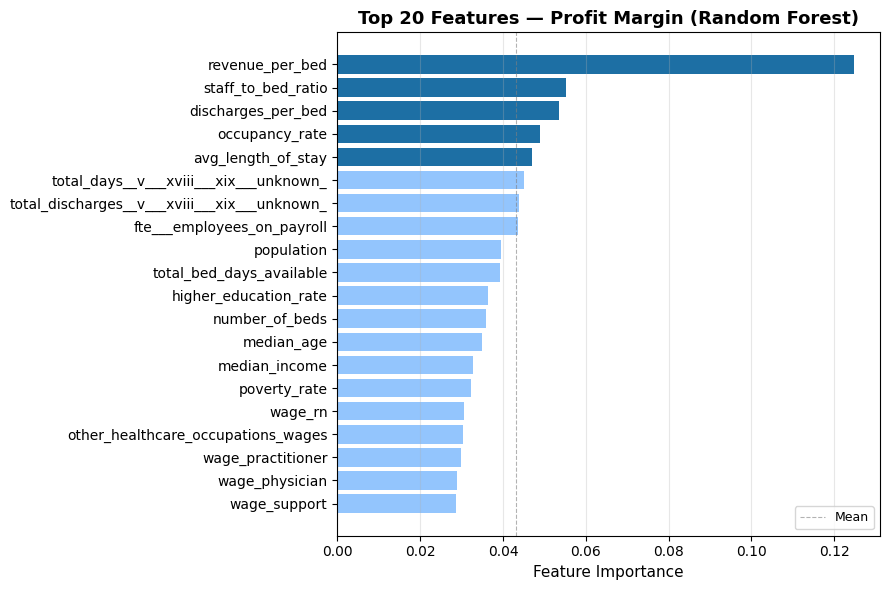

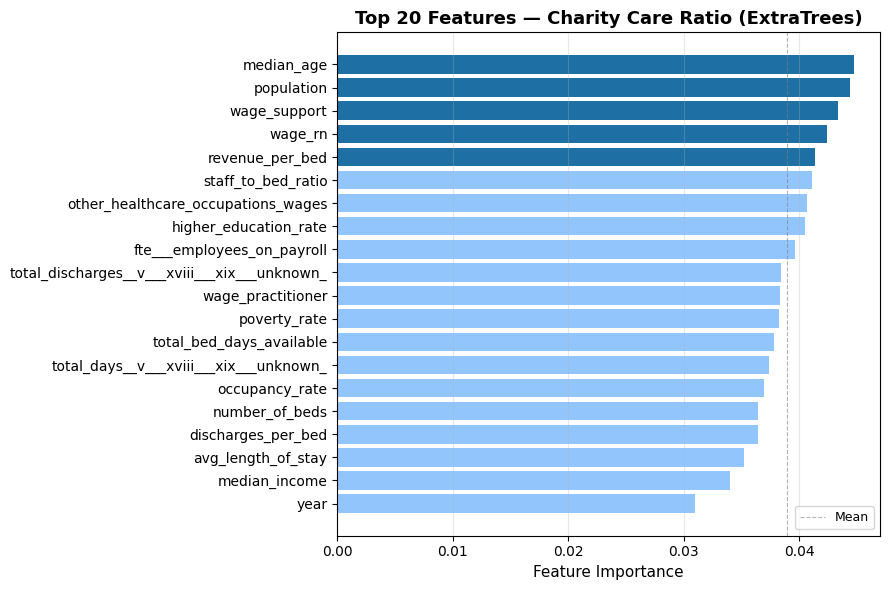

In [12]:
# Feature importance plots

def get_feature_names(pipeline):
    ohe = pipeline.named_steps['preprocessor'] \
                  .named_transformers_['cat'] \
                  .named_steps['ohe']
    return NUMERICAL_FEATURES + ohe.get_feature_names_out(CATEGORICAL_FEATURES).tolist()

def plot_importance(pipeline, title, top_n=20):
    names = get_feature_names(pipeline)
    fi = pd.Series(
        pipeline.named_steps['model'].feature_importances_,
        index=names
    ).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(9, 6))
    colors = ['#1D6FA4' if i < 5 else '#93c5fd' for i in range(len(fi))]
    ax.barh(fi.index[::-1], fi.values[::-1], color=colors[::-1])
    ax.set_xlabel('Feature Importance', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axvline(fi.values.mean(), color='gray', linestyle='--',
               alpha=0.6, linewidth=0.8, label='Mean')
    ax.legend(fontsize=9)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_importance(pipe_pm,  'Top 20 Features — Profit Margin (Random Forest)')
plot_importance(pipe_ccr, 'Top 20 Features — Charity Care Ratio (ExtraTrees)')

In [13]:
# Save models

PM_FILE  = os.path.join(OUTPUT_DIR, 'final_rf_profit_margin.pkl')
CCR_FILE = os.path.join(OUTPUT_DIR, 'final_et_charity_care.pkl')

joblib.dump(pipe_pm,  PM_FILE)
joblib.dump(pipe_ccr, CCR_FILE)

print(f'Saved: {PM_FILE}')
print(f'Saved: {CCR_FILE}')

# Also save the feature lists so pipeline.py can verify at load time
joblib.dump({
    'numerical':   NUMERICAL_FEATURES,
    'categorical': CATEGORICAL_FEATURES,
    'all':         ALL_FEATURES,
    'targets':     TARGETS,
}, os.path.join(OUTPUT_DIR, 'feature_metadata.pkl'))

print(f'Saved: {os.path.join(OUTPUT_DIR, "feature_metadata.pkl")}')

Saved: C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\app\models\final_rf_profit_margin.pkl
Saved: C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\app\models\final_et_charity_care.pkl
Saved: C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\app\models\feature_metadata.pkl


In [ ]:
# Verification of saved models
# Loads both pkl files and runs a quick prediction to confirm they work

loaded_pm  = joblib.load(PM_FILE)
loaded_ccr = joblib.load(CCR_FILE)

sample = X_test.head(5).copy()

print('Sample predictions on 5 test rows:')
print(pd.DataFrame({
    'Actual PM':        y_pm_test.head(5).values.round(4),
    'Predicted PM':     loaded_pm.predict(sample).round(4),
    'Actual CCR':       y_ccr_test.head(5).values.round(4),
    'Predicted CCR':    loaded_ccr.predict(sample).round(4),
}).to_string(index=False))

print('\nVerification complete — models are working correctly.')
print(f'\nFiles saved to: {OUTPUT_DIR}')
print(f'  PM model:  final_rf_profit_margin.pkl')
print(f'  CCR model: final_et_charity_care.pkl')

Sample predictions on 5 test rows:
 Actual PM  Predicted PM  Actual CCR  Predicted CCR
   -0.1568        0.0669      0.0147         0.0203
   -0.4926        0.0567      0.0090         0.0147
   -0.0332        0.0317      0.0028         0.0118
    0.1262        0.0155      0.0166         0.0358
    0.0817        0.0531      0.0209         0.0183

Verification complete — models are working correctly.

Files saved to: C:\Users\manju\OneDrive\Desktop\Documents\Data Analytics\DA Semester 4\Capstone 2\app\models
  PM model:  final_rf_profit_margin.pkl
  CCR model: final_et_charity_care.pkl

Update pipeline.py CCR_MODEL_FILE to: "final_et_charity_care.pkl"
